<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/lecture_notes/notebooks/04_ARMA_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 실습: AR, MA, ARMA 모형의 기초
**Notebook:** `04_ARMA_Modeling.ipynb`

## 실습 목표 (Learning Objectives)
이 실습에서는 다음을 수행합니다.

1. AR(1), MA(1), ARMA(1,1) 과정을 직접 시뮬레이션하여 구조적 차이를 확인합니다.
2. 각 과정의 시계열 플롯과 ACF/PACF 패턴을 비교합니다.
3. 정상성(Stationarity)이 ARMA 적용의 전제라는 점을 실제 데이터로 확인합니다.
4. 실제 금융 수익률 데이터에 대해 AR, MA, ARMA 모형을 적합하고 AIC/BIC를 비교합니다.
5. 잔차의 자기상관 여부를 Ljung-Box 검정으로 점검합니다.
6. 가장 적절한 차수의 ARMA 모형을 선택하고 간단한 예측까지 수행합니다.

---

## 왜 이 실습이 중요한가?
ARMA는 정상 시계열을 다루는 가장 고전적인 기준 모형입니다.  
시계열이 과거 자신의 값에 의존하는지(AR), 과거의 충격에 의존하는지(MA), 혹은 둘 다 반영하는지(ARMA)를 구분하는 일은 이후 ARIMA, SARIMA, VAR, 머신러닝 모델을 이해하는 데도 중요한 기초가 됩니다.

이번 실습의 핵심은 단순히 함수를 실행하는 것이 아니라, **시계열의 기억 구조가 ACF/PACF와 잔차 진단에서 어떻게 드러나는지**를 직접 확인하는 데 있습니다.


In [1]:
# ============================================
# 1. 필수 라이브러리 불러오기
# ============================================
# pandas: 데이터 처리
# numpy: 수치 계산
# matplotlib: 시각화
# warnings: 불필요한 경고 메시지 제어
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from IPython.display import display


## 1. 온라인 환경 준비
이번 실습은 Google Colab 또는 Jupyter Notebook에서 바로 실행할 수 있도록 구성했습니다.

실제 금융 수익률 예시를 위해 `yfinance`를 사용합니다.  
설치되어 있지 않다면 자동으로 설치합니다.


In [2]:
# ============================================
# 2. yfinance 설치 및 임포트
# ============================================

try:
    import yfinance as yf
    print("yfinance가 이미 설치되어 있습니다.")
except ImportError:
    print("yfinance가 설치되어 있지 않아 지금 설치합니다...")
    !pip -q install yfinance
    import yfinance as yf
    print("yfinance 설치가 완료되었습니다.")


yfinance가 이미 설치되어 있습니다.


## 2. 시각화 기본 설정
이번 버전도 Colab 호환성을 위해 **그래프 텍스트는 영어**로 출력합니다.  
마크다운 셀과 코드 주석은 한글로 유지합니다.


In [3]:
# ============================================
# 3. 시각화 기본 설정
# ============================================

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False


## 3. AR, MA, ARMA 과정을 위한 도구 불러오기
이번 장의 핵심은 세 가지 과정의 차이를 직접 보는 것입니다.

- **AR(1)**: 현재값이 직전값에 의존
- **MA(1)**: 현재값이 직전 충격에 의존
- **ARMA(1,1)**: 두 구조를 함께 반영

이를 위해 `statsmodels`의 `ArmaProcess`를 활용합니다.


In [4]:
# ============================================
# 4. ARMA 시뮬레이션 도구 및 진단 함수 불러오기
# ============================================

from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA


## 4. 시뮬레이션 데이터 생성
여기서는 다음 세 가지 과정을 만듭니다.

1. **AR(1)** with <code>φ = 0.7</code>  
2. **MA(1)** with <code>θ = 0.7</code>  
3. **ARMA(1,1)** with <code>φ = 0.6</code>, <code>θ = 0.5</code>  

시뮬레이션의 목적은 이론을 그래프와 ACF/PACF로 연결하는 것입니다.


In [5]:
# ============================================
# 5. AR(1), MA(1), ARMA(1,1) 시뮬레이션
# ============================================
# statsmodels의 ArmaProcess는 다항식 부호 규칙을 사용합니다.
# AR(1): y_t = 0.7 y_(t-1) + e_t
# => ar = [1, -0.7]
# MA(1): y_t = e_t + 0.7 e_(t-1)
# => ma = [1, 0.7]
# ============================================

np.random.seed(123)
n = 500

# AR(1)
ar1_process = ArmaProcess(np.array([1, -0.7]), np.array([1]))
ar1_series = pd.Series(ar1_process.generate_sample(nsample=n), name="AR1")

# MA(1)
ma1_process = ArmaProcess(np.array([1]), np.array([1, 0.7]))
ma1_series = pd.Series(ma1_process.generate_sample(nsample=n), name="MA1")

# ARMA(1,1)
arma11_process = ArmaProcess(np.array([1, -0.6]), np.array([1, 0.5]))
arma11_series = pd.Series(arma11_process.generate_sample(nsample=n), name="ARMA11")

display(pd.DataFrame({
    "AR1": ar1_series.head(10),
    "MA1": ma1_series.head(10),
    "ARMA11": arma11_series.head(10)
}))


,AR1,MA1,ARMA11
0,-1.085631,0.752034,-0.748827
1,0.237404,0.596064,-0.256115
2,0.449161,-0.216697,0.848279
3,-1.191882,0.743773,-0.131338
4,-1.412918,1.911530,-0.103595
5,0.662394,2.220029,-1.693208
6,-1.963003,-0.054057,-2.152833
7,-1.803015,-1.227639,-2.527278
8,0.003826,-2.075609,-2.891190
9,-0.864062,-1.429612,-3.414641


## 5. 세 과정의 시계열 플롯 비교
이제 세 과정을 그래프로 비교해 보겠습니다.

관찰 포인트는 다음과 같습니다.

- AR(1)은 값이 서서히 이어지는 느낌이 있는가?
- MA(1)은 충격의 흔적이 짧게 남는가?
- ARMA(1,1)은 두 효과가 혼합된 모습인가?


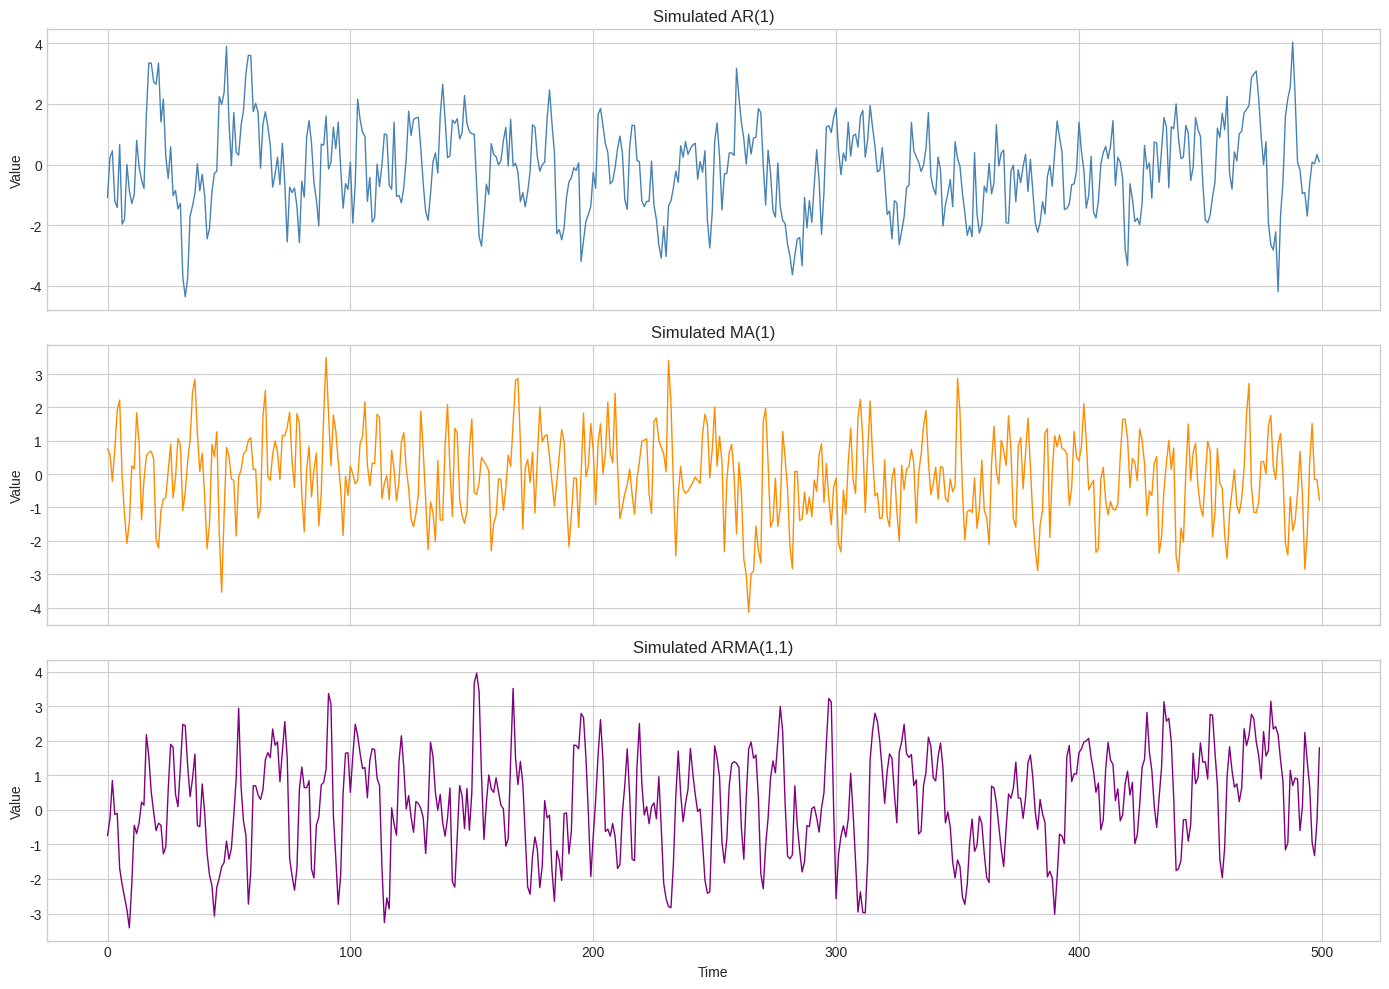

In [6]:
# ============================================
# 6. AR, MA, ARMA 시계열 플롯
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(ar1_series, color="steelblue", linewidth=1)
axes[0].set_title("Simulated AR(1)")
axes[0].set_ylabel("Value")

axes[1].plot(ma1_series, color="darkorange", linewidth=1)
axes[1].set_title("Simulated MA(1)")
axes[1].set_ylabel("Value")

axes[2].plot(arma11_series, color="purple", linewidth=1)
axes[2].set_title("Simulated ARMA(1,1)")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Value")

plt.tight_layout()
plt.show()


## 6. ACF와 PACF 패턴 비교
ARMA 모형 식별의 핵심은 ACF와 PACF의 패턴을 읽는 것입니다.

일반적인 직관은 다음과 같습니다.

- **AR(p)**: PACF가 비교적 뚜렷하게 끊기고, ACF는 점진적으로 감소
- **MA(q)**: ACF가 비교적 뚜렷하게 끊기고, PACF는 점진적으로 감소
- **ARMA(p,q)**: ACF와 PACF가 모두 점진적으로 감소

실제 데이터에서는 이론만큼 깔끔하지 않기 때문에, 시각적 판단과 정보 기준(AIC/BIC)을 함께 써야 합니다.


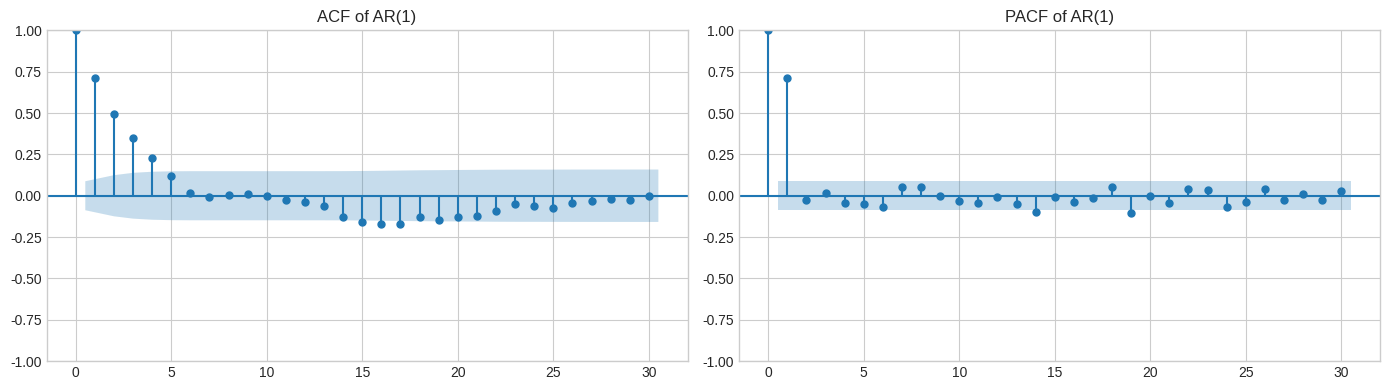

In [7]:
# ============================================
# 7. AR(1)의 ACF / PACF
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ar1_series, lags=30, ax=axes[0])
plot_pacf(ar1_series, lags=30, ax=axes[1], method="ywm")

axes[0].set_title("ACF of AR(1)")
axes[1].set_title("PACF of AR(1)")

plt.tight_layout()
plt.show()


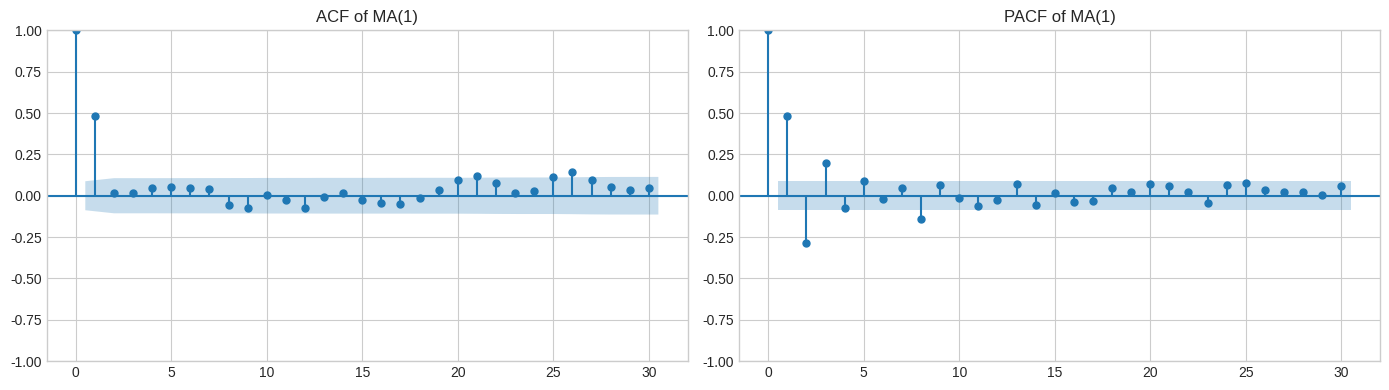

In [8]:
# ============================================
# 8. MA(1)의 ACF / PACF
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ma1_series, lags=30, ax=axes[0])
plot_pacf(ma1_series, lags=30, ax=axes[1], method="ywm")

axes[0].set_title("ACF of MA(1)")
axes[1].set_title("PACF of MA(1)")

plt.tight_layout()
plt.show()


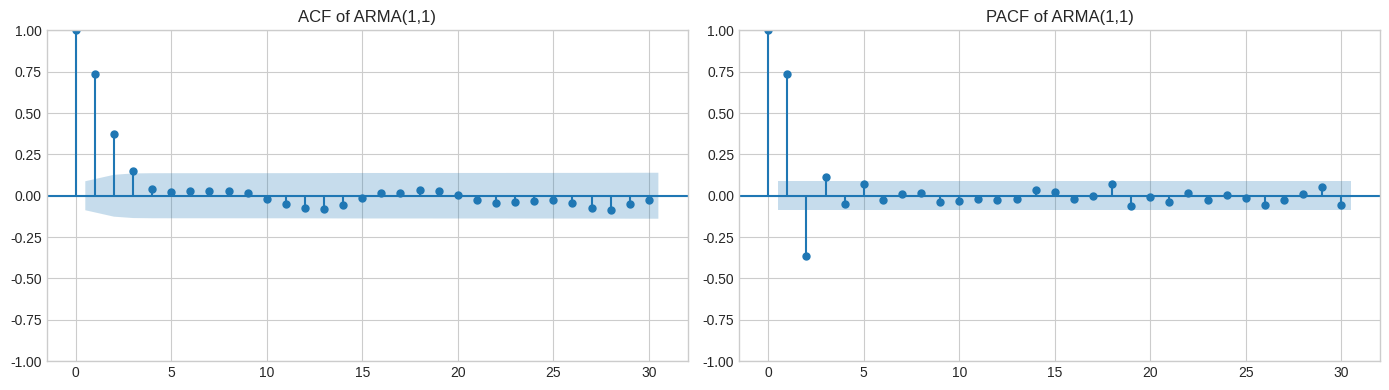

In [9]:
# ============================================
# 9. ARMA(1,1)의 ACF / PACF
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(arma11_series, lags=30, ax=axes[0])
plot_pacf(arma11_series, lags=30, ax=axes[1], method="ywm")

axes[0].set_title("ACF of ARMA(1,1)")
axes[1].set_title("PACF of ARMA(1,1)")

plt.tight_layout()
plt.show()


## 7. 정상성 전제 점검
ARMA는 **정상 시계열**을 전제로 합니다.  
따라서 실제 데이터에 적용하기 전에 최소한 기본적인 정상성 점검이 필요합니다.

여기서는 ADF 검정을 사용합니다.

- 귀무가설: 단위근이 존재한다 (비정상)
- p-value가 충분히 작으면 정상성 쪽에 더 가까움


In [10]:
# ============================================
# 10. ADF 검정 함수
# ============================================

def adf_report(series, name="Series"):
    series = pd.Series(series).dropna()
    result = adfuller(series, autolag="AIC")
    print(f"===== {name} =====")
    print("ADF Statistic :", round(result[0], 4))
    print("ADF p-value   :", round(result[1], 4))
    print("-" * 40)


In [11]:
# ============================================
# 11. 시뮬레이션 데이터의 정상성 점검
# ============================================

adf_report(ar1_series, "AR(1)")
adf_report(ma1_series, "MA(1)")
adf_report(arma11_series, "ARMA(1,1)")


===== AR(1) =====
ADF Statistic : -9.1638
ADF p-value   : 0.0
----------------------------------------
===== MA(1) =====
ADF Statistic : -6.811
ADF p-value   : 0.0
----------------------------------------
===== ARMA(1,1) =====
ADF Statistic : -7.6864
ADF p-value   : 0.0
----------------------------------------


## 8. 실제 금융 데이터 불러오기
이제 실제 데이터로 넘어가겠습니다.  
이번에는 **애플(AAPL)** 의 일별 주가를 받아서 **로그 수익률(Log Return)** 을 계산합니다.

ARMA는 일반적으로 가격 수준보다 **차분된 값 또는 수익률**에 더 자연스럽게 적용됩니다.


In [12]:
# ============================================
# 12. 실제 금융 데이터 다운로드
# ============================================

ticker = "AAPL"
start_date = "2020-01-01"
end_date = "2024-12-31"

df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))

print(f"Ticker: {ticker}")
print(f"Shape: {df.shape}")
display(df.head())


Ticker: AAPL
Shape: (1257, 7)


Price,Adj Close,Close,High,Low,Open,Volume,Log_Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,,
2020-01-02,72.400513,75.087502,75.150002,73.797501,74.059998,135480400,NaN
2020-01-03,71.696648,74.357498,75.144997,74.125000,74.287498,146322800,-0.009770
2020-01-06,72.267921,74.949997,74.989998,73.187500,73.447502,118387200,0.007937
2020-01-07,71.928024,74.597504,75.224998,74.370003,74.959999,108872000,-0.004714
2020-01-08,73.085121,75.797501,76.110001,74.290001,74.290001,132079200,0.015958


## 9. 가격 수준과 수익률 비교
가격 수준과 수익률을 같이 보면 왜 ARMA를 수익률에 적용하는지 더 잘 이해할 수 있습니다.

관찰 포인트는 다음과 같습니다.

- 가격은 장기 추세를 가지는가?
- 수익률은 0 근처에서 움직이는가?
- 변동성 군집이 보이는가?


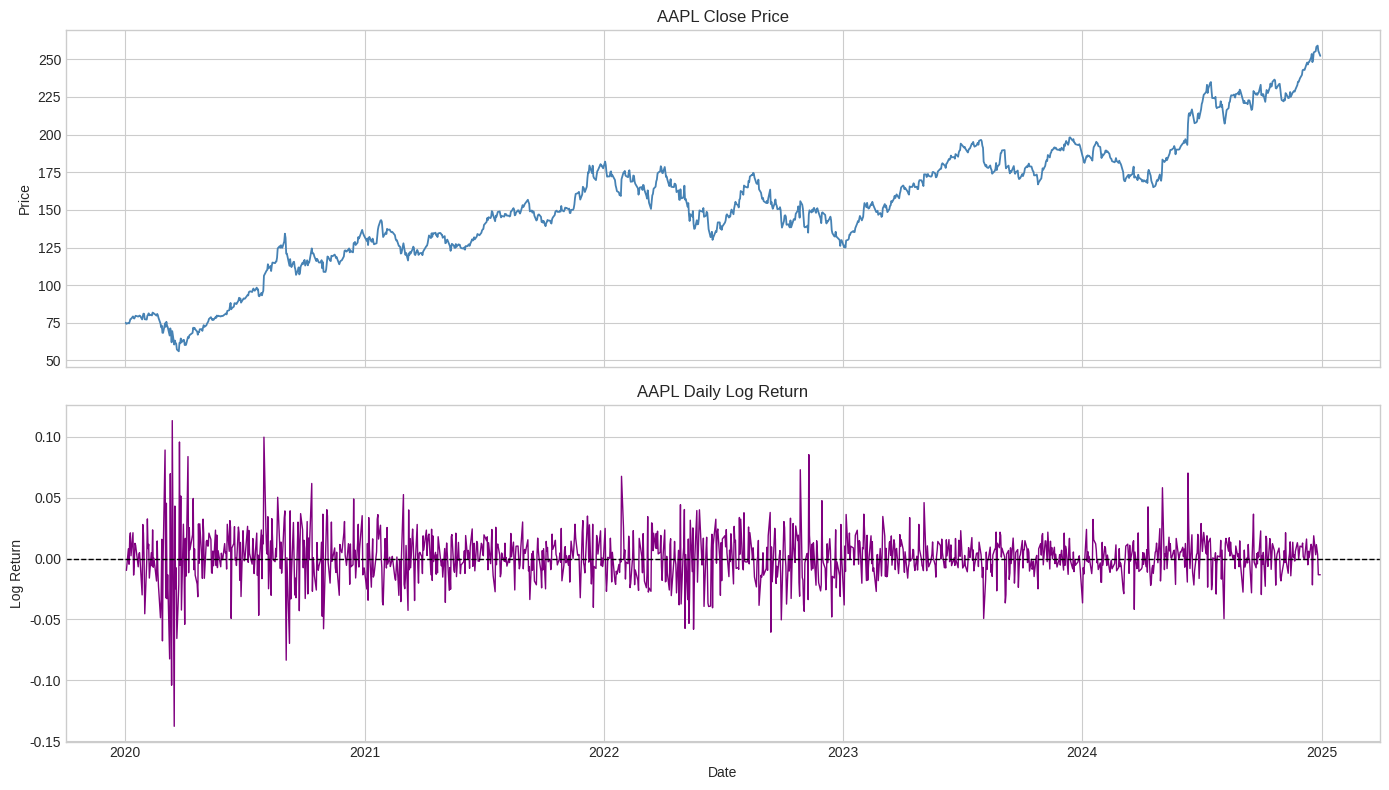

In [13]:
# ============================================
# 13. 가격 수준과 로그 수익률 플롯
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df["Close"], color="steelblue", linewidth=1.3)
axes[0].set_title("AAPL Close Price")
axes[0].set_ylabel("Price")

axes[1].plot(df.index, df["Log_Return"], color="purple", linewidth=1)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("AAPL Daily Log Return")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Log Return")

plt.tight_layout()
plt.show()


In [16]:
# ============================================
# 14. 가격과 수익률의 ADF 검정
# ============================================

# The DataFrame 'df' has a MultiIndex for its columns (e.g., ('Close', 'AAPL')).
# The previous attempt used ('AAPL', 'Close'), which caused a KeyError.
# To fix this, we explicitly select the column using its correct MultiIndex tuple.
# 'Log_Return' was added as a single-level column, so it can be accessed directly.
adf_report(df[('Close', 'AAPL')].dropna(), "AAPL Close Price")
adf_report(df["Log_Return"].dropna(), "AAPL Log Return")

===== AAPL Close Price =====
ADF Statistic : -0.7258
ADF p-value   : 0.84
----------------------------------------
===== AAPL Log Return =====
ADF Statistic : -11.2834
ADF p-value   : 0.0
----------------------------------------


## 10. 수익률의 ACF/PACF 확인
실제 데이터는 시뮬레이션처럼 깔끔하지 않지만, 그래도 ACF/PACF를 통해 대략적인 차수 후보를 생각해 볼 수 있습니다.


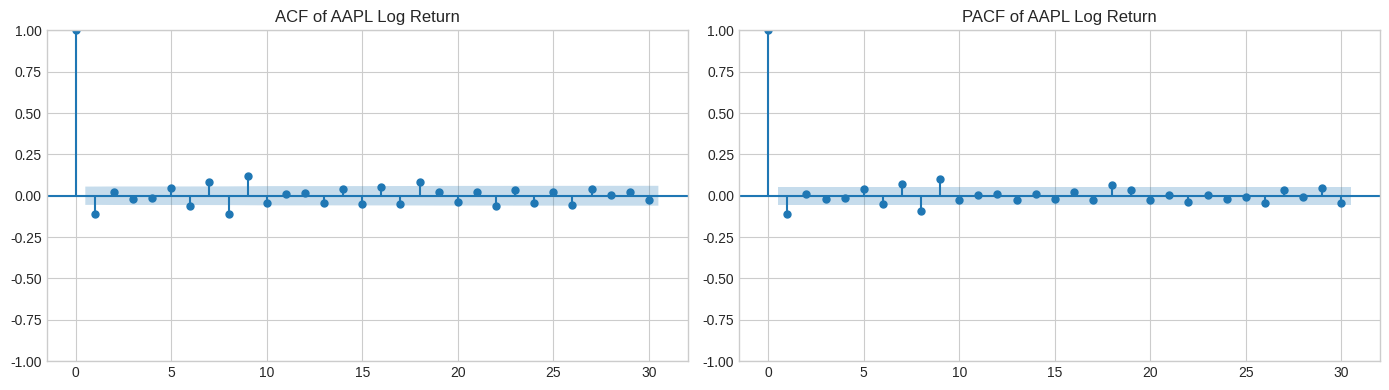

In [17]:
# ============================================
# 15. 실제 수익률의 ACF / PACF
# ============================================

returns = df["Log_Return"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(returns, lags=30, ax=axes[0])
plot_pacf(returns, lags=30, ax=axes[1], method="ywm")

axes[0].set_title("ACF of AAPL Log Return")
axes[1].set_title("PACF of AAPL Log Return")

plt.tight_layout()
plt.show()


## 11. AR, MA, ARMA 모형 적합
`statsmodels`에서는 ARMA를 `ARIMA(order=(p, 0, q))` 형태로 적합할 수 있습니다.  
즉, 차분 차수 <code>d = 0</code>이면 ARMA 모형이 됩니다.

여기서는 먼저 세 가지 단순 후보를 적합합니다.

- AR(1) = ARIMA(1,0,0)
- MA(1) = ARIMA(0,0,1)
- ARMA(1,1) = ARIMA(1,0,1)


In [18]:
# ============================================
# 16. 후보 모형 적합
# ============================================

model_ar1 = ARIMA(returns, order=(1, 0, 0)).fit()
model_ma1 = ARIMA(returns, order=(0, 0, 1)).fit()
model_arma11 = ARIMA(returns, order=(1, 0, 1)).fit()

comparison_df = pd.DataFrame({
    "Model": ["AR(1)", "MA(1)", "ARMA(1,1)"],
    "AIC": [model_ar1.aic, model_ma1.aic, model_arma11.aic],
    "BIC": [model_ar1.bic, model_ma1.bic, model_arma11.bic]
})

display(comparison_df.sort_values("AIC"))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,Model,AIC,BIC
0,AR(1),-6279.986757,-6264.579695
1,MA(1),-6279.602446,-6264.195384
2,"ARMA(1,1)",-6278.099986,-6257.557236


## 12. AIC/BIC 기반 차수 탐색
실제 데이터에서는 AR(1), MA(1), ARMA(1,1)만으로는 충분하지 않을 수 있습니다.  
따라서 작은 범위에서 <code>p</code>와 <code>q</code>를 바꿔가며 AIC를 비교해 보겠습니다.

여기서는 단순 예시로 <code>p, q = 0, 1, 2, 3</code> 범위를 탐색합니다.


In [19]:
# ============================================
# 17. ARMA(p,q) 그리드 탐색
# ============================================

results_list = []

for p in range(4):
    for q in range(4):
        if p == 0 and q == 0:
            continue
        try:
            fitted = ARIMA(returns, order=(p, 0, q)).fit()
            results_list.append({
                "p": p,
                "q": q,
                "AIC": fitted.aic,
                "BIC": fitted.bic
            })
        except Exception:
            pass

grid_df = pd.DataFrame(results_list).sort_values("AIC").reset_index(drop=True)
display(grid_df.head(10))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,p,q,AIC,BIC
0,1,2,-6282.349246,-6256.670810
1,2,2,-6280.523552,-6249.709428
2,1,0,-6279.986757,-6264.579695
3,0,1,-6279.602446,-6264.195384
4,1,1,-6278.099986,-6257.557236
5,2,0,-6278.072131,-6257.529381
6,0,2,-6277.929405,-6257.386656
7,0,3,-6276.626370,-6250.947933
8,3,0,-6276.435366,-6250.756929
9,2,1,-6276.052592,-6250.374155


## 13. 최적 모형 적합 및 요약표 확인
이제 AIC가 가장 낮은 모형을 선택하여 다시 적합하고 결과를 확인합니다.


In [20]:
# ============================================
# 18. 최적 차수 선택 및 최종 적합
# ============================================

best_p = int(grid_df.loc[0, "p"])
best_q = int(grid_df.loc[0, "q"])

best_model = ARIMA(returns, order=(best_p, 0, best_q)).fit()

print(f"Best ARMA order by AIC: ({best_p}, {best_q})")
print(best_model.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Best ARMA order by AIC: (1, 2)
                               SARIMAX Results                                
Dep. Variable:             Log_Return   No. Observations:                 1256
Model:                 ARIMA(1, 0, 2)   Log Likelihood                3146.175
Date:                Sun, 15 Mar 2026   AIC                          -6282.349
Time:                        01:27:05   BIC                          -6256.671
Sample:                             0   HQIC                         -6272.698
                               - 1256                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.001      1.919      0.055   -2.06e-05       0.002
ar.L1         -0.9228      0.045    -20.694      0.000      -1.010      -0.835
ma.L1          0.8229

## 14. 잔차 진단
좋은 ARMA 모형은 데이터의 구조를 충분히 설명한 뒤, 잔차가 **백색잡음**에 가까워져야 합니다.

여기서는 다음을 점검합니다.

1. 잔차 시계열 플롯
2. 잔차의 ACF
3. Ljung-Box 검정


In [21]:
# ============================================
# 19. 잔차 추출
# ============================================

resid = best_model.resid

display(resid.head())


,0
Date,
2020-01-03,-0.010732
2020-01-06,0.005892
2020-01-07,-0.005350
2020-01-08,0.014853
2020-01-09,0.021076


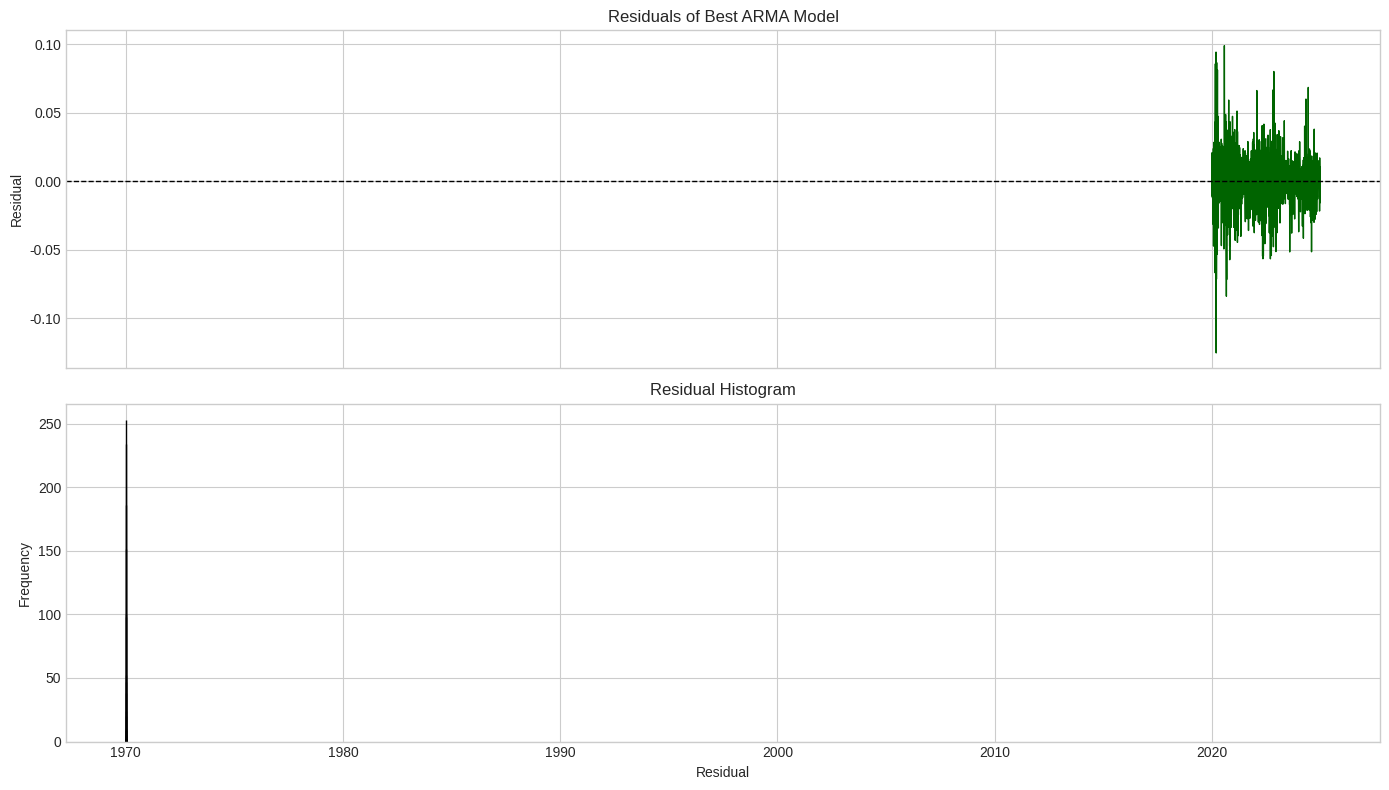

In [22]:
# ============================================
# 20. 잔차 시각화
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(resid, color="darkgreen", linewidth=1)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Residuals of Best ARMA Model")
axes[0].set_ylabel("Residual")

axes[1].hist(resid, bins=30, edgecolor="black")
axes[1].set_title("Residual Histogram")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


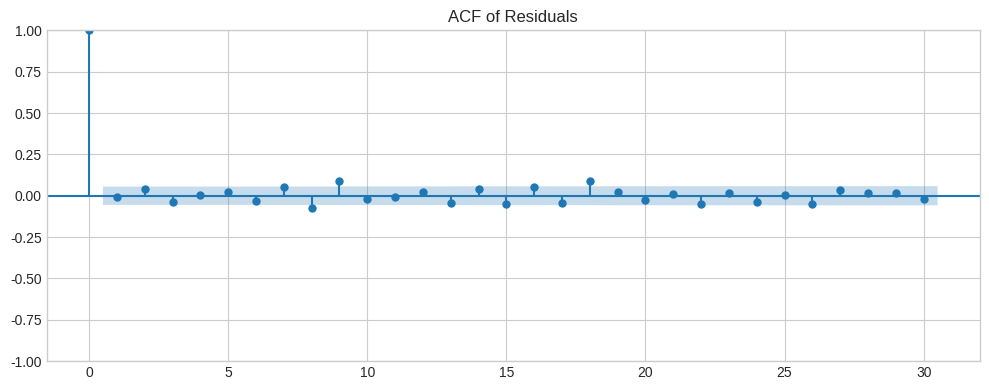

In [23]:
# ============================================
# 21. 잔차의 ACF
# ============================================

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resid.dropna(), lags=30, ax=ax)
ax.set_title("ACF of Residuals")

plt.tight_layout()
plt.show()


In [24]:
# ============================================
# 22. Ljung-Box 검정
# ============================================
# 귀무가설: 잔차에 자기상관이 없다
# p-value가 충분히 크면 잔차가 백색잡음에 가깝다고 볼 수 있습니다.
# ============================================

lb_df = acorr_ljungbox(resid.dropna(), lags=[10, 20], return_df=True)
display(lb_df)


,lb_stat,lb_pvalue
10,27.472730,0.002191
20,53.372559,0.000072


## 15. 간단한 예측 실습
ARMA 모형은 정상 시계열의 짧은 미래를 예측하는 데 사용할 수 있습니다.  
여기서는 간단히 마지막 구간을 학습용으로 두고, 이후 몇 스텝을 예측해 보겠습니다.


In [25]:
# ============================================
# 23. 학습/테스트 분할
# ============================================

split_idx = int(len(returns) * 0.9)

train = returns.iloc[:split_idx]
test = returns.iloc[split_idx:]

print("Train length:", len(train))
print("Test length :", len(test))


Train length: 1130
Test length : 126


In [26]:
# ============================================
# 24. 학습 데이터로 최종 모형 재적합 및 예측
# ============================================

forecast_model = ARIMA(train, order=(best_p, 0, best_q)).fit()
forecast_result = forecast_model.get_forecast(steps=len(test))

forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

display(pd.DataFrame({
    "Actual": test.head(),
    "Forecast": forecast_mean.head()
}))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,Actual,Forecast
2024-07-02 00:00:00,0.016109,NaN
2024-07-03 00:00:00,0.005794,NaN
2024-07-05 00:00:00,0.021390,NaN
2024-07-08 00:00:00,0.006518,NaN
2024-07-09 00:00:00,0.003768,NaN
1130,NaN,-0.002723
1131,NaN,0.001564
1132,NaN,0.000309
1133,NaN,0.001543
1134,NaN,0.000330


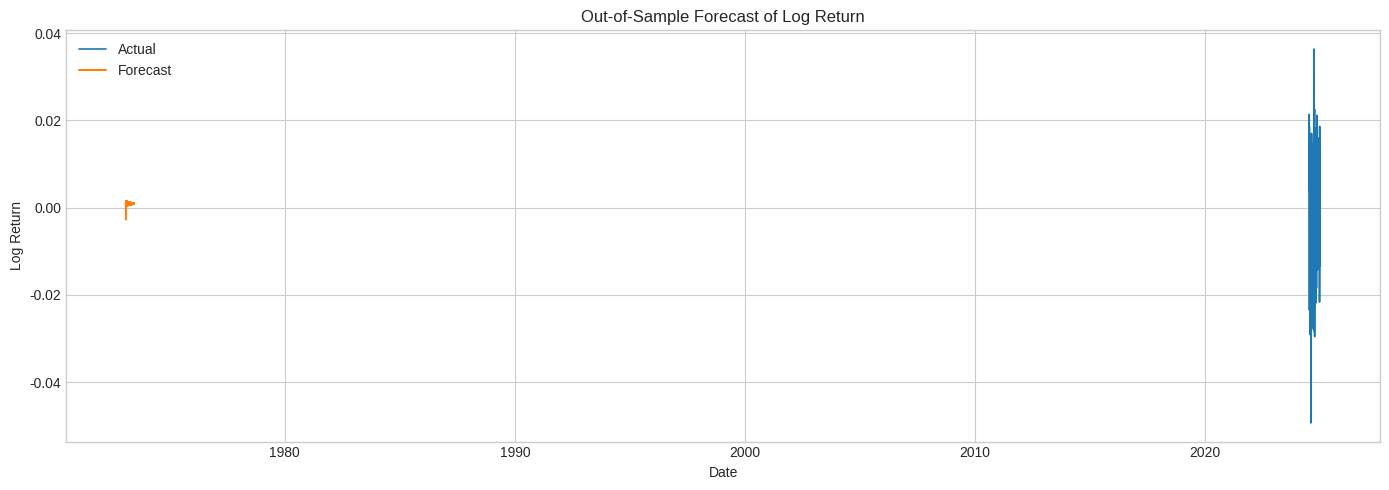

In [27]:
# ============================================
# 25. 실제값과 예측값 비교
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(test.index, test, label="Actual", linewidth=1.2)
plt.plot(forecast_mean.index, forecast_mean, label="Forecast", linewidth=1.5)

plt.title("Out-of-Sample Forecast of Log Return")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.tight_layout()
plt.show()


## 16. 예측 오차 간단 확인
수익률 데이터는 매우 잡음이 크기 때문에, 예측력이 높지 않을 수 있습니다.  
그 자체가 금융 시계열의 중요한 특징이기도 합니다.

여기서는 MAE와 RMSE를 단순 계산해 봅니다.


In [28]:
# ============================================
# 26. 간단한 예측 오차 계산
# ============================================

mae = np.mean(np.abs(test - forecast_mean))
rmse = np.sqrt(np.mean((test - forecast_mean) ** 2))

print("MAE :", round(mae, 6))
print("RMSE:", round(rmse, 6))


MAE : nan
RMSE: nan


## 17. 실습 정리
이번 실습에서 확인한 핵심은 다음과 같습니다.

- AR 과정은 과거 자신의 값에 대한 기억을 반영한다.
- MA 과정은 과거 충격의 흔적을 반영한다.
- ARMA 과정은 두 구조를 동시에 포함한다.
- ACF/PACF는 차수 식별의 출발점이지만, 실제 데이터에서는 완벽하지 않다.
- ARMA는 정상 시계열에 적용해야 하며, 실제 금융 데이터에서는 수익률에 더 자연스럽게 적용된다.
- 최종 모형은 반드시 잔차 진단을 통해 자기상관이 남지 않는지 점검해야 한다.


## 18. 연습문제 (Exercises)

1. 시뮬레이션에서 AR(2) 또는 MA(2) 과정을 직접 만들어 보고 ACF/PACF 패턴이 어떻게 달라지는지 비교하시오.

2. 애플(AAPL) 대신 테슬라(TSLA) 또는 마이크로소프트(MSFT) 수익률에 대해 같은 ARMA 그리드 탐색을 수행하시오.

3. AIC와 BIC가 서로 다른 최적 모형을 가리킬 경우, 왜 그런 차이가 생길 수 있는지 설명하시오.

4. 최적 모형의 잔차에 대해 다시 ACF와 Ljung-Box 검정을 수행하고, 잔차가 백색잡음인지 자신의 언어로 해석하시오.

5. 실제 금융 수익률 예측에서 MAE와 RMSE가 크지 않더라도, 왜 경제적으로 유의미한 예측이라고 말하기 어려울 수 있는지 논의하시오.
